In [1]:
import numpy as np
import scipy
import scanpy as sc
import scvelo as scv
import cellrank as cr
import scgeo as sg

In [2]:
# Inputs (adjust if needed)
AB_IN = "data/GSE280305_paths_AB.h5ad"          # contains X_pca_raw, X_scanorama, X_umap_raw, X_umap_scanorama, leiden_raw
# Optionally also load scalars/h5ad with CellRank outputs elsewhere; Phase 1 QC does not require it.

ab = sc.read_h5ad(AB_IN)
ab


AnnData object with n_obs × n_vars = 31605 × 3000
    obs: 'timepoint', 'sample', 'gsm', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden_raw'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'hvg', 'leiden_raw', 'leiden_raw_colors', 'log1p', 'nbrs_raw', 'nbrs_scanorama', 'pca', 'timepoint_colors', 'umap'
    obsm: 'X_pca', 'X_pca_raw', 'X_scanorama', 'X_umap', 'X_umap_raw', 'X_umap_scanorama'
    varm: 'PCs'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'
    obsp: 'nbrs_raw_connect

In [3]:
C_IN = "data/GSE280305_pathC_gpcca.h5ad"
#C_IN = "data/GSE280305_velocity_full.h5ad"
adata = sc.read_h5ad(C_IN)
adata

AnnData object with n_obs × n_vars = 31605 × 1500
    obs: 'timepoint', 'sample', 'gsm', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'macrostates_fwd', 'term_states_fwd', 'term_states_fwd_probs'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    uns: 'coarse_fwd', 'eigendecomposition_fwd', 'lineages_gpcca_names', 'macrostates_fwd_colors', 'neighbors', 'pca', 'schur_matrix_fwd', 'term_states_fwd_colors', 'timepoint_colors', 'velocity_graph', 'velocity_graph_neg', 'velocity_params'
    obsm: 'X_pca', 'X_umap', 'X_umap_raw', 'X_umap_scanorama', 'lineages_fwd', 'lineages_gpcca', 'macrostates_fwd_memberships', 'schur_vectors_fwd', 'term_states_fwd_memberships', 'velocity_umap'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'ambiguous', 'matrix', 'spliced', 'unspliced', 

In [4]:
adata.obs["leiden_raw"] = ab.obs.loc[adata.obs_names, "leiden_raw"].astype(str).values

In [5]:
del ab

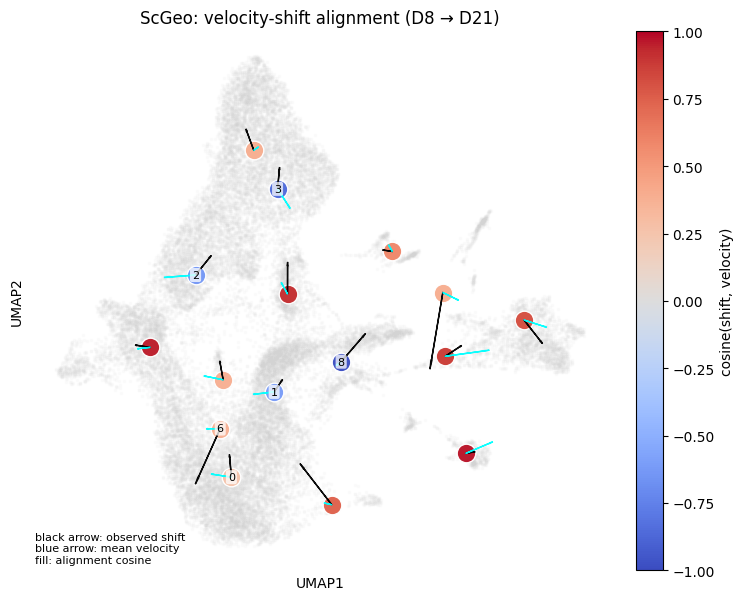

(<Figure size 820x700 with 2 Axes>,
 <Axes: title={'center': 'ScGeo: velocity-shift alignment (D8 → D21)'}, xlabel='UMAP1', ylabel='UMAP2'>)

In [6]:
sg.pl.velocity_shift_alignment(
    adata,
    node_key="leiden_raw",
    condition_key="timepoint",
    group0="D8",
    group1="D21",
    basis="umap",
    velocity_basis="umap",
    min_cells=20,
    label_top_n=6,
    label_mode="discordant",
)

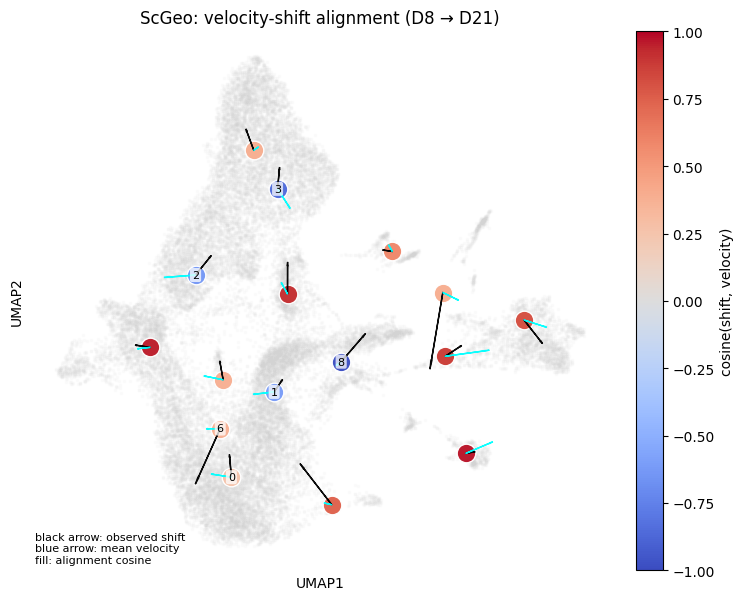

In [7]:
fig, ax, align_df = sg.pl.velocity_shift_alignment(
    adata,
    node_key="leiden_raw",
    condition_key="timepoint",
    group0="D8",
    group1="D21",
    basis="umap",
    velocity_basis="umap",
    min_cells=20,
    label_top_n=6,
    label_mode="discordant",
    return_data=True,
)

In [8]:
align_df[[
    "leiden_raw",
    "shift_norm",
    "vel_norm",
    "alignment_cosine",
    "alignment_class",
]].sort_values("alignment_cosine")

,leiden_raw,shift_norm,vel_norm,alignment_cosine,alignment_class
14,8,1.843146,0.005963,-0.980512,discordant
9,3,1.157981,0.023636,-0.844359,discordant
8,2,1.249590,0.027853,-0.630472,discordant
1,1,0.753710,0.018752,-0.606842,discordant
0,0,1.210500,0.018295,0.255122,neutral
12,6,3.144079,0.012365,0.367413,aligned
7,15,1.015910,0.017520,0.377150,aligned
11,5,1.184373,0.005419,0.383669,aligned
4,12,4.106452,0.016148,0.387865,aligned
6,14,0.436115,0.007774,0.581283,aligned


In [9]:
discordant_nodes = (
    align_df.loc[align_df["alignment_class"] == "discordant", "leiden_raw"]
    .astype(str)
    .tolist()
)

aligned_nodes = (
    align_df.loc[align_df["alignment_class"] == "aligned", "leiden_raw"]
    .astype(str)
    .tolist()
)

In [10]:
adata_discordant = adata[adata.obs["leiden_raw"].astype(str).isin(discordant_nodes)].copy()
adata_aligned = adata[adata.obs["leiden_raw"].astype(str).isin(aligned_nodes)].copy()

In [11]:
import pandas as pd

In [12]:
pd.crosstab(
    adata.obs["timepoint"],
    adata.obs["leiden_raw"].astype(str).isin(discordant_nodes),
    normalize="index",
)

leiden_raw,False,True
timepoint,,
D8,0.622177,0.377823
D11,0.863727,0.136273
D14,0.624332,0.375668
D21,0.385881,0.614119


In [13]:
summary = (
    align_df.groupby("alignment_class")
    .agg(
        n_nodes=("leiden_raw", "size"),
        mean_shift=("shift_norm", "mean"),
        mean_vel=("vel_norm", "mean"),
        mean_cosine=("alignment_cosine", "mean"),
    )
    .sort_values("mean_cosine")
)
summary

,n_nodes,mean_shift,mean_vel,mean_cosine
alignment_class,,,,
discordant,4,1.251107,0.019051,-0.765546
neutral,1,1.210500,0.018295,0.255122
aligned,11,1.608486,0.016246,0.667744


In [14]:
pd.DataFrame({
    "aligned_nodes": aligned_nodes,
})

,aligned_nodes
0,10
1,11
2,12
3,13
4,14
5,15
6,4
7,5
8,6
9,7


In [15]:
pd.DataFrame({
    "discordant_nodes": discordant_nodes,
})

,discordant_nodes
0,1
1,2
2,3
3,8


In [16]:
import pandas as pd

aligned_time = (
    adata_aligned.obs["timepoint"]
    .astype(str)
    .value_counts()
    .reindex(["D8", "D11", "D14", "D21"], fill_value=0)
)

discordant_time = (
    adata_discordant.obs["timepoint"]
    .astype(str)
    .value_counts()
    .reindex(["D8", "D11", "D14", "D21"], fill_value=0)
)

time_compare = pd.DataFrame({
    "aligned_n": aligned_time,
    "discordant_n": discordant_time,
})

time_compare["aligned_frac"] = time_compare["aligned_n"] / time_compare["aligned_n"].sum()
time_compare["discordant_frac"] = time_compare["discordant_n"] / time_compare["discordant_n"].sum()
time_compare

,aligned_n,discordant_n,aligned_frac,discordant_frac
timepoint,,,,
D8,3223,4968,0.237230,0.387913
D11,3888,615,0.286177,0.048021
D14,3311,2109,0.243707,0.164676
D21,3164,5115,0.232887,0.399391


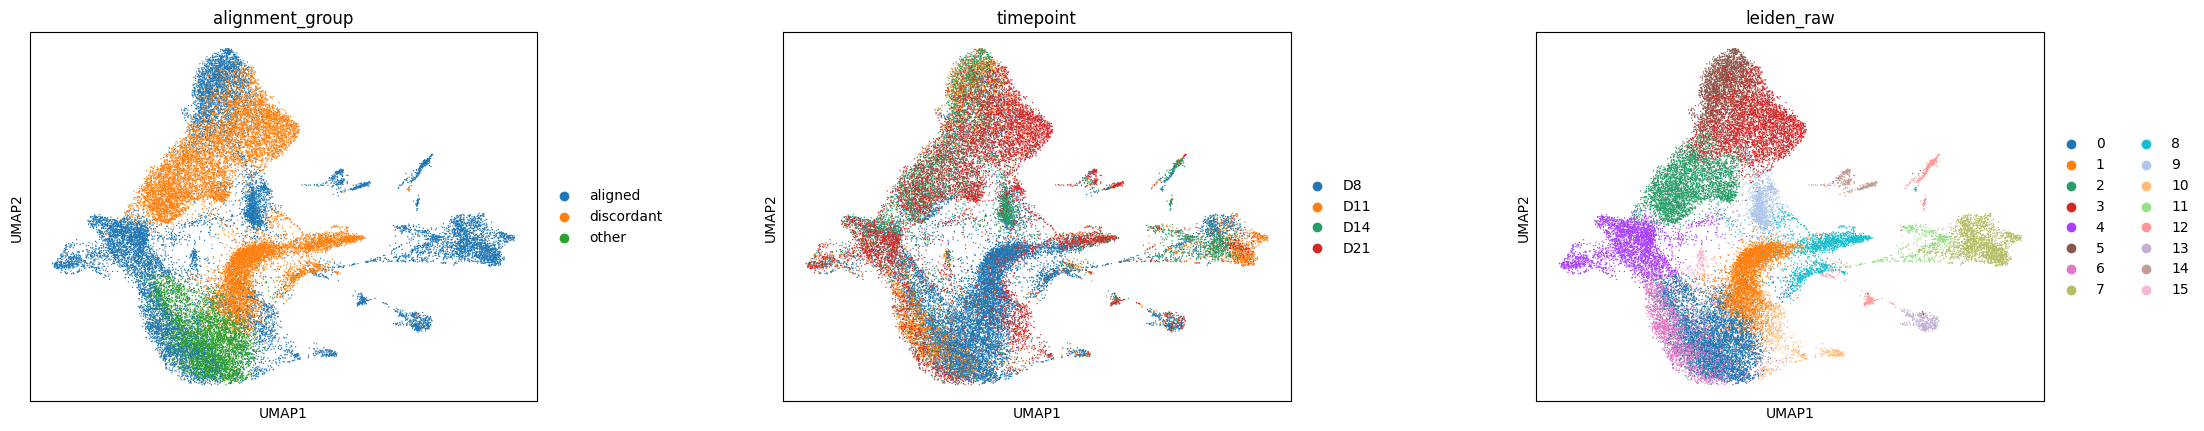

In [17]:
adata.obs["alignment_group"] = "other"
adata.obs.loc[
    adata.obs["leiden_raw"].astype(str).isin(aligned_nodes),
    "alignment_group"
] = "aligned"
adata.obs.loc[
    adata.obs["leiden_raw"].astype(str).isin(discordant_nodes),
    "alignment_group"
] = "discordant"

sc.pl.umap(
    adata,
    color=["alignment_group", "timepoint", "leiden_raw"],

    wspace=0.35,
)

In [18]:
vel_compare = (
    align_df.groupby("alignment_class")["vel_norm"]
    .describe()
)
vel_compare

,count,mean,std,min,25%,50%,75%,max
alignment_class,,,,,,,,
aligned,11.0,0.016246,0.009918,0.005419,0.009664,0.013590,0.019391,0.039256
discordant,4.0,0.019051,0.009485,0.005963,0.015555,0.021194,0.024690,0.027853
neutral,1.0,0.018295,NaN,0.018295,0.018295,0.018295,0.018295,0.018295


In [19]:
shift_compare = (
    align_df.groupby("alignment_class")["shift_norm"]
    .describe()
)
shift_compare

,count,mean,std,min,25%,50%,75%,max
alignment_class,,,,,,,,
aligned,11.0,1.608486,1.193741,0.422065,0.796952,1.184373,2.146849,4.106452
discordant,4.0,1.251107,0.449662,0.753710,1.056913,1.203786,1.397979,1.843146
neutral,1.0,1.210500,NaN,1.210500,1.210500,1.210500,1.210500,1.210500


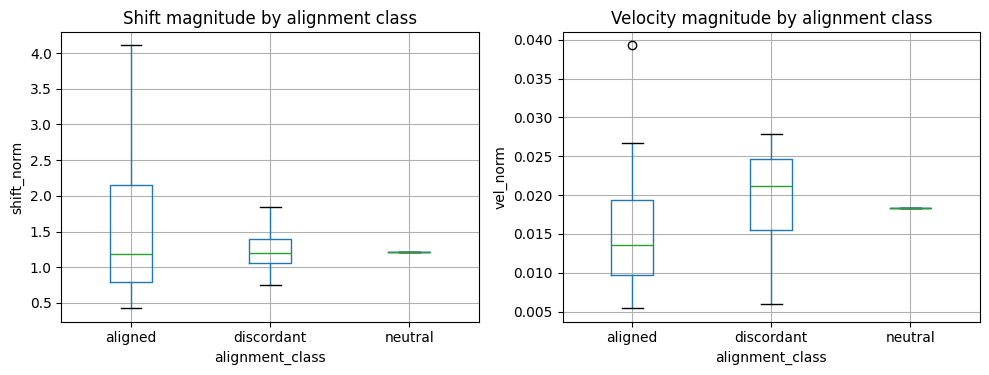

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

align_df.boxplot(column="shift_norm", by="alignment_class", ax=axes[0])
axes[0].set_title("Shift magnitude by alignment class")
axes[0].set_ylabel("shift_norm")

align_df.boxplot(column="vel_norm", by="alignment_class", ax=axes[1])
axes[1].set_title("Velocity magnitude by alignment class")
axes[1].set_ylabel("vel_norm")

plt.suptitle("")
plt.tight_layout()
plt.show()

In [21]:
pd.crosstab(
    adata.obs["alignment_group"],
    adata.obs["macrostates_fwd"],
    normalize="index"
)

macrostates_fwd,0,1,2,3,4,5
alignment_group,,,,,,
aligned,0.208333,0.208333,0.208333,0.166667,0.208333,0.000000
discordant,0.000000,0.000000,0.000000,0.166667,0.000000,0.833333


In [22]:
pd.crosstab(
    adata.obs["alignment_group"],
    adata.obs["macrostates_fwd"]
)

macrostates_fwd,0,1,2,3,4,5
alignment_group,,,,,,
aligned,30,30,30,24,30,0
discordant,0,0,0,6,0,30


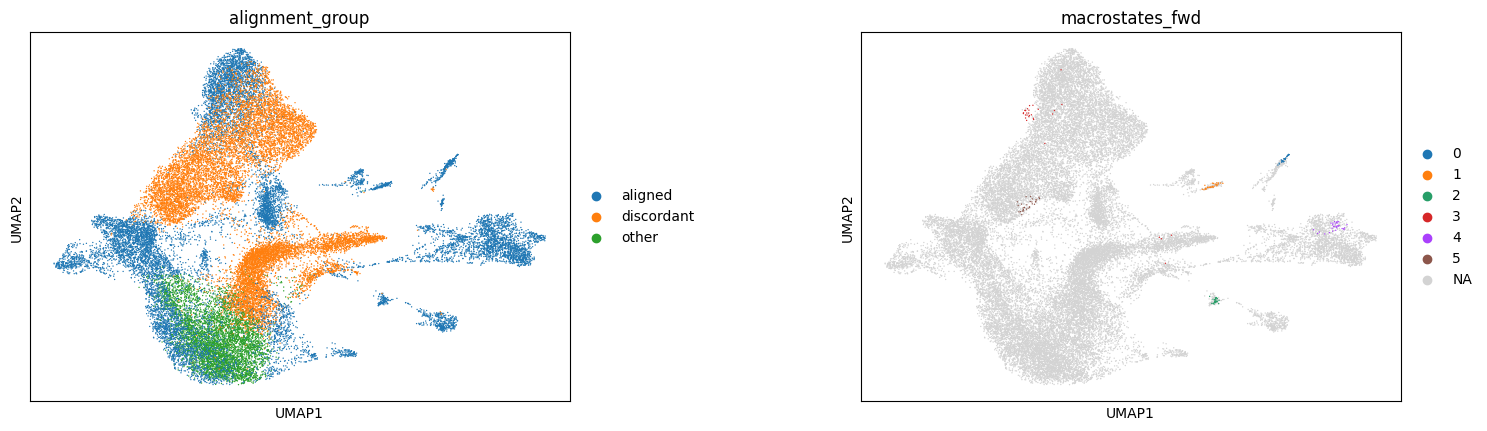

In [23]:
sc.pl.umap(
    adata,
    color=["alignment_group", "macrostates_fwd"],
    wspace=0.4
)

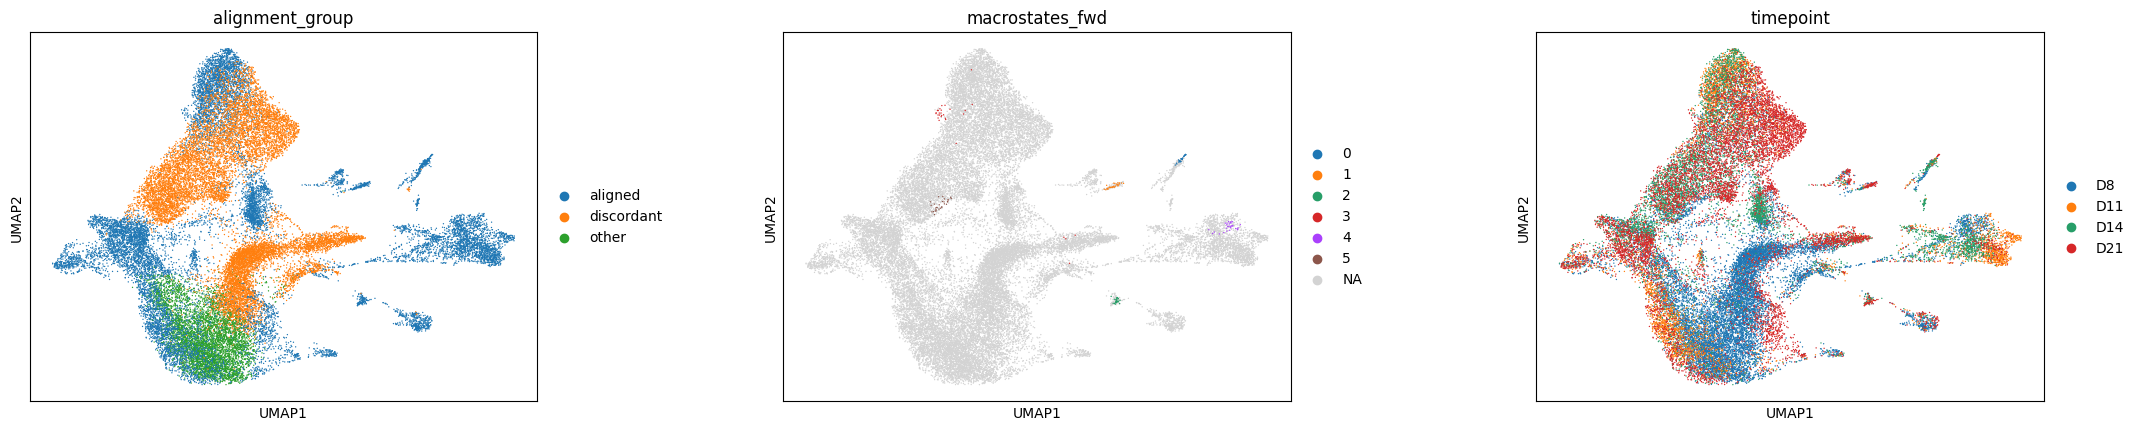

In [24]:
sc.pl.embedding(
    adata,
    basis="umap",
    color=["alignment_group","macrostates_fwd","timepoint"],
    wspace=0.35
)

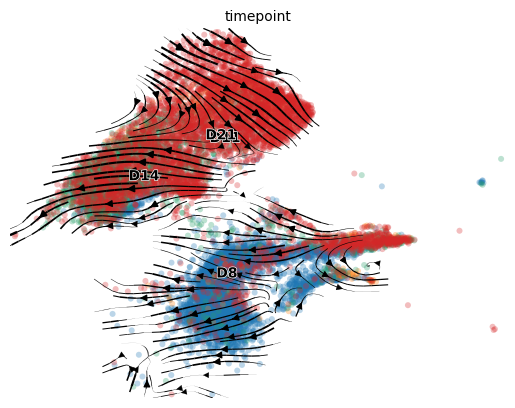

In [25]:
scv.pl.velocity_embedding_stream(
    adata_discordant,
    basis="umap",
    color="timepoint"
)

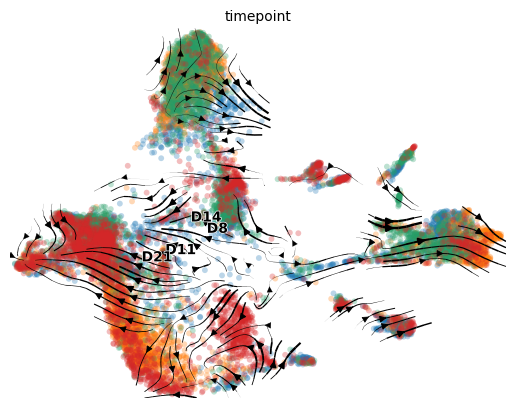

In [26]:
scv.pl.velocity_embedding_stream(
    adata_aligned,
    basis="umap",
    color="timepoint"
)

In [27]:
for ad in [adata_aligned, adata_discordant]:
    # remove stale neighbor graph metadata copied from parent object
    for k in ["neighbors"]:
        if k in ad.uns:
            del ad.uns[k]

    for k in ["connectivities", "distances"]:
        if k in ad.obsp:
            del ad.obsp[k]

    sc.pp.neighbors(ad, n_neighbors=30, use_rep="X_pca")
    scv.pp.moments(ad, n_pcs=None, n_neighbors=None)
    scv.tl.velocity(ad)
    scv.tl.velocity_graph(ad)

computing moments based on connectivities
    finished (0:00:01) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities
    finished (0:00:02) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/6 cores)


  0%|          | 0/13586 [00:00<?, ?cells/s]

    finished (0:00:26) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing moments based on connectivities
    finished (0:00:01) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities
    finished (0:00:01) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/6 cores)


  0%|          | 0/12807 [00:00<?, ?cells/s]

    finished (0:00:14) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


computing velocity embedding
    finished (0:00:02) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


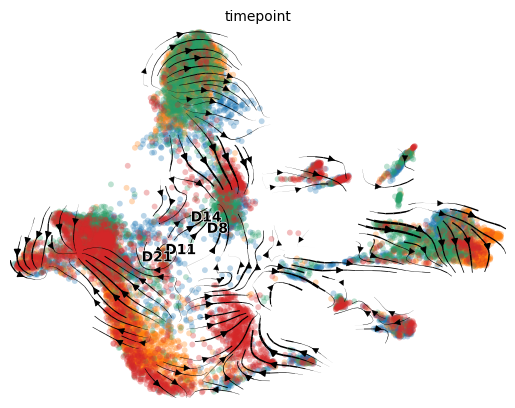

computing velocity embedding
    finished (0:00:02) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


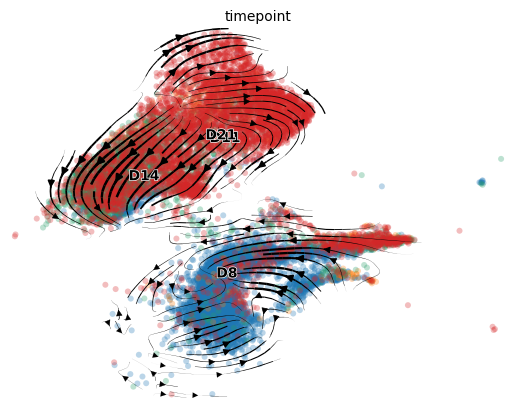

In [28]:
scv.pl.velocity_embedding_stream(
    adata_aligned,
    basis="umap",
    color="timepoint",
)

scv.pl.velocity_embedding_stream(
    adata_discordant,
    basis="umap",
    color="timepoint",
)

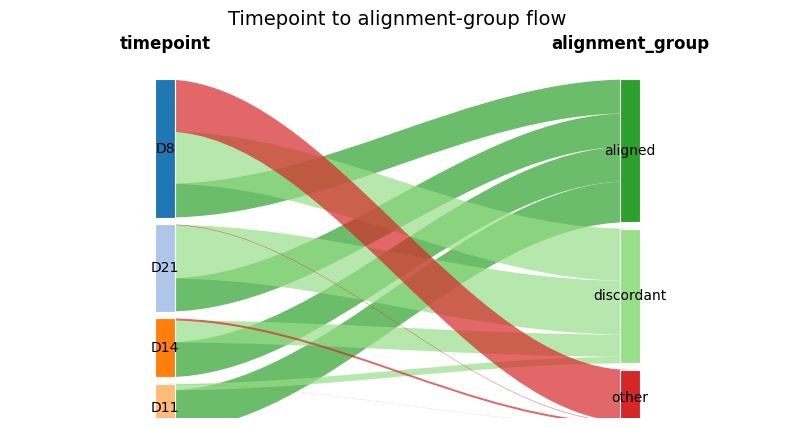

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Timepoint to alignment-group flow'}>)

In [29]:
sg.pl.state_flow_alluvial(
    adata,
    columns=["timepoint", "alignment_group"],
    title="Timepoint to alignment-group flow",
    color_by="target",
    figsize=(10, 5),
)

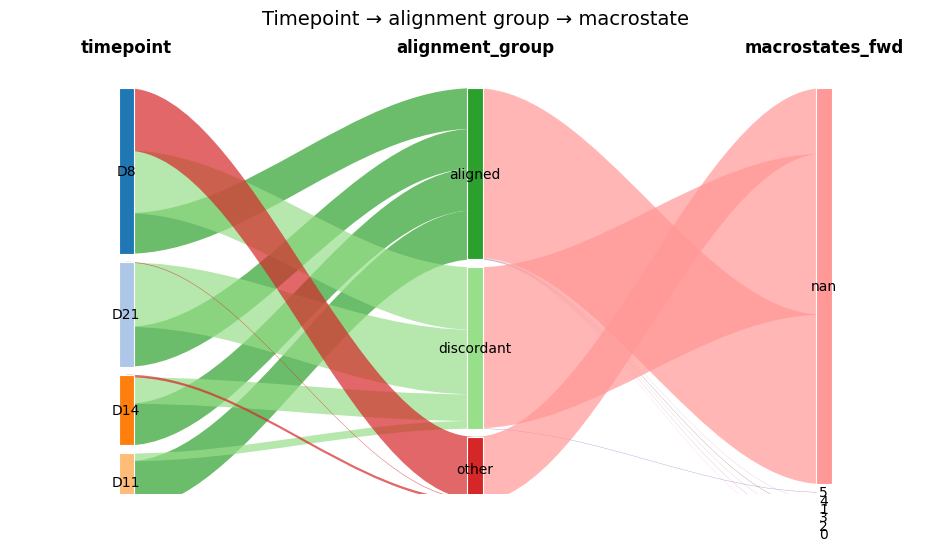

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Timepoint → alignment group → macrostate'}>)

In [30]:
sg.pl.state_flow_alluvial(
    adata,
    columns=["timepoint", "alignment_group", "macrostates_fwd"],
    title="Timepoint → alignment group → macrostate",
    color_by="target",
    figsize=(12, 6),
    min_count=20,
)

In [31]:
adata.write("data/pathC_alignment.h5ad")